<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML</b></center>

<center><b><h1>Lab - 9</b></center>    
<pre>    

# Step 1: Import Libraries
This step imports all necessary libraries for data processing, visualization, and machine learning.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load the Dataset
Load Given dataset -  heart.csv

In [4]:
df=pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [5]:
df.shape

(1025, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(723)

# Step 4: Univariate Analysis
Here we visualize the distribution of each feature using histograms.

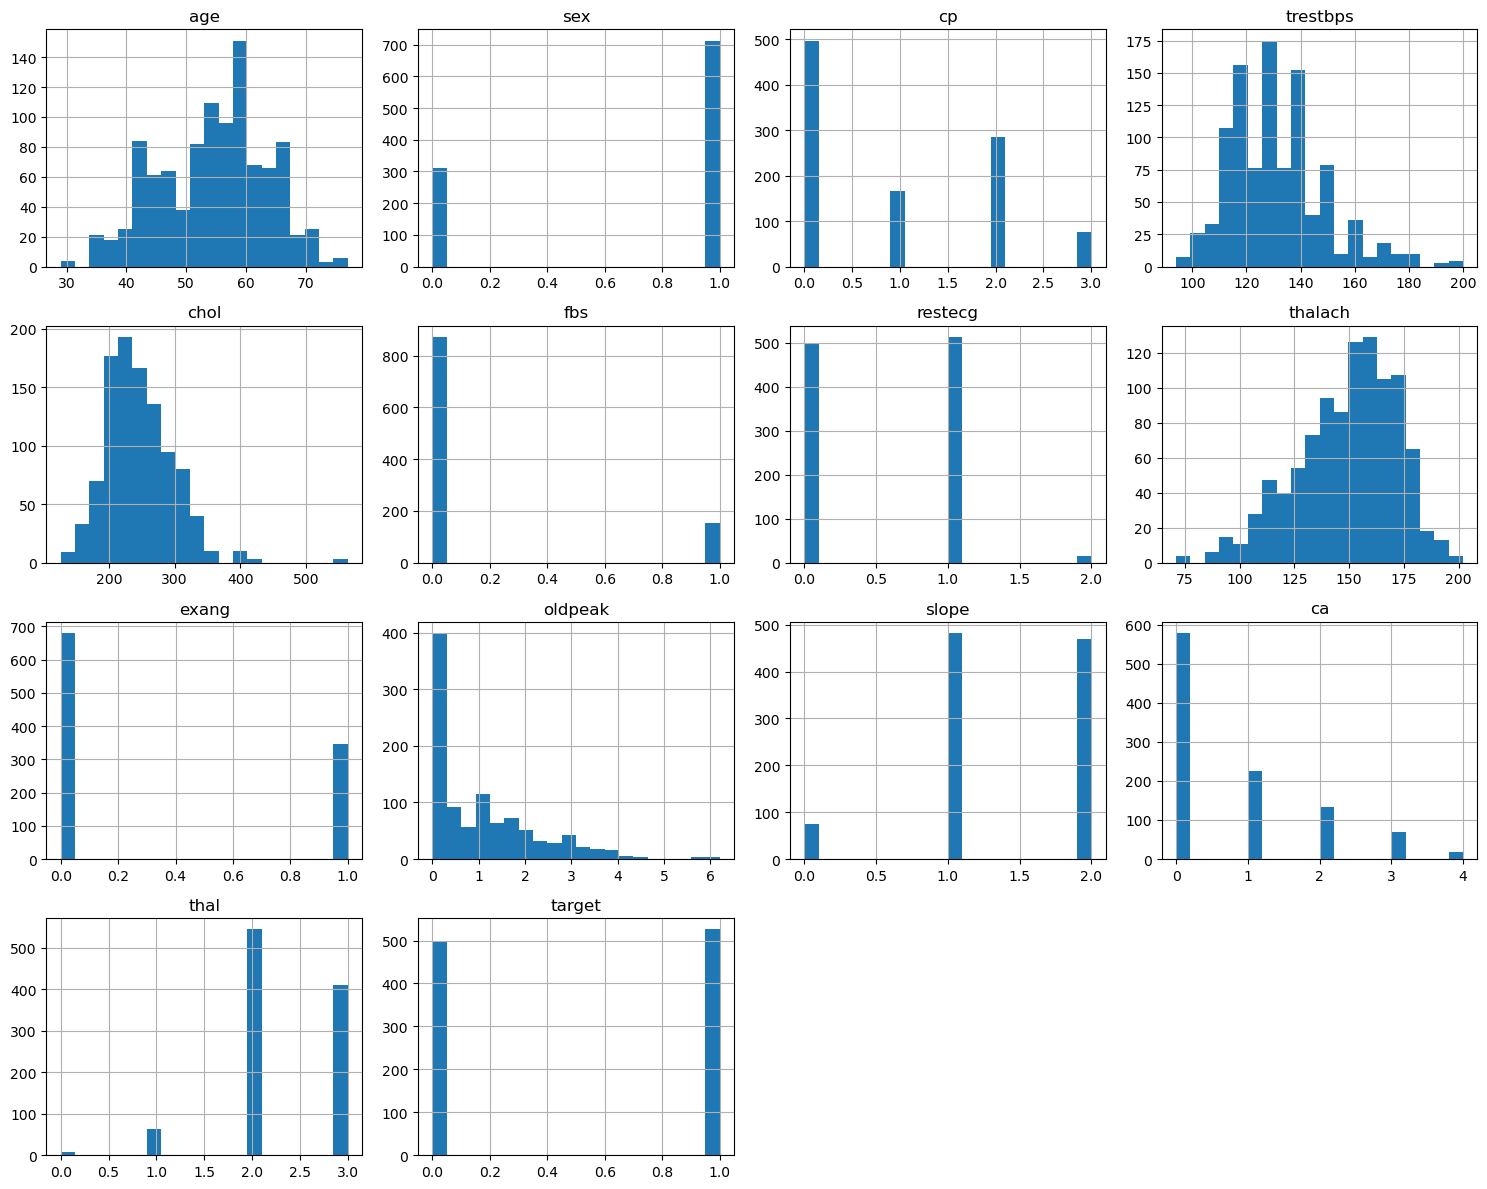

In [10]:
df.hist(figsize=(15,12),bins=20)
plt.tight_layout()
plt.show()

# Step 5: Bivariate Analysis
This step involves exploring the correlations between features using a heatmap.

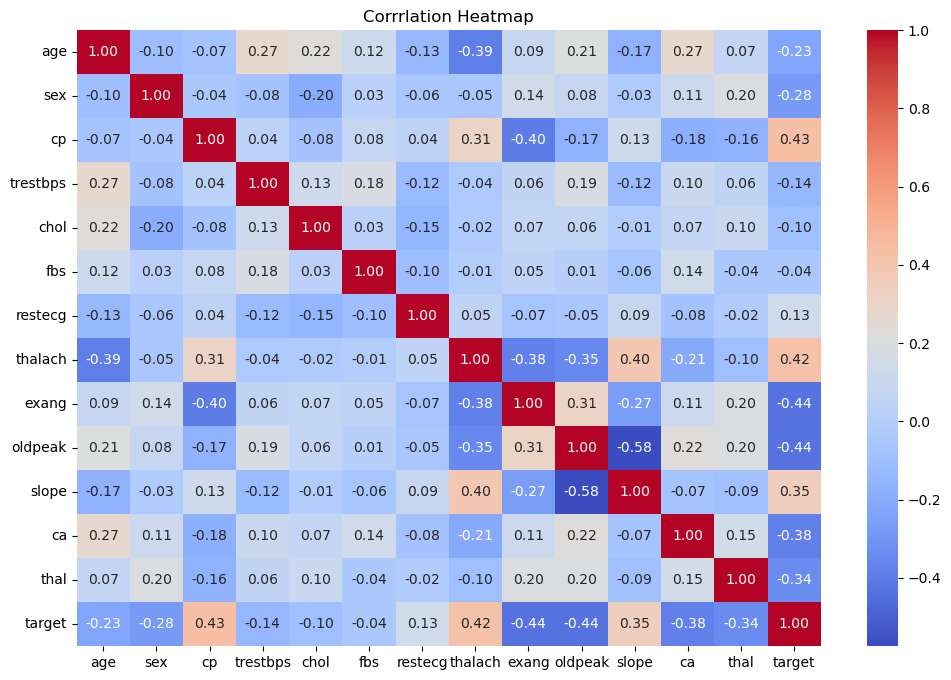

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Corrrlation Heatmap")
plt.show()

# Step 6: Outlier Detection
We visualize potential outliers using boxplots.

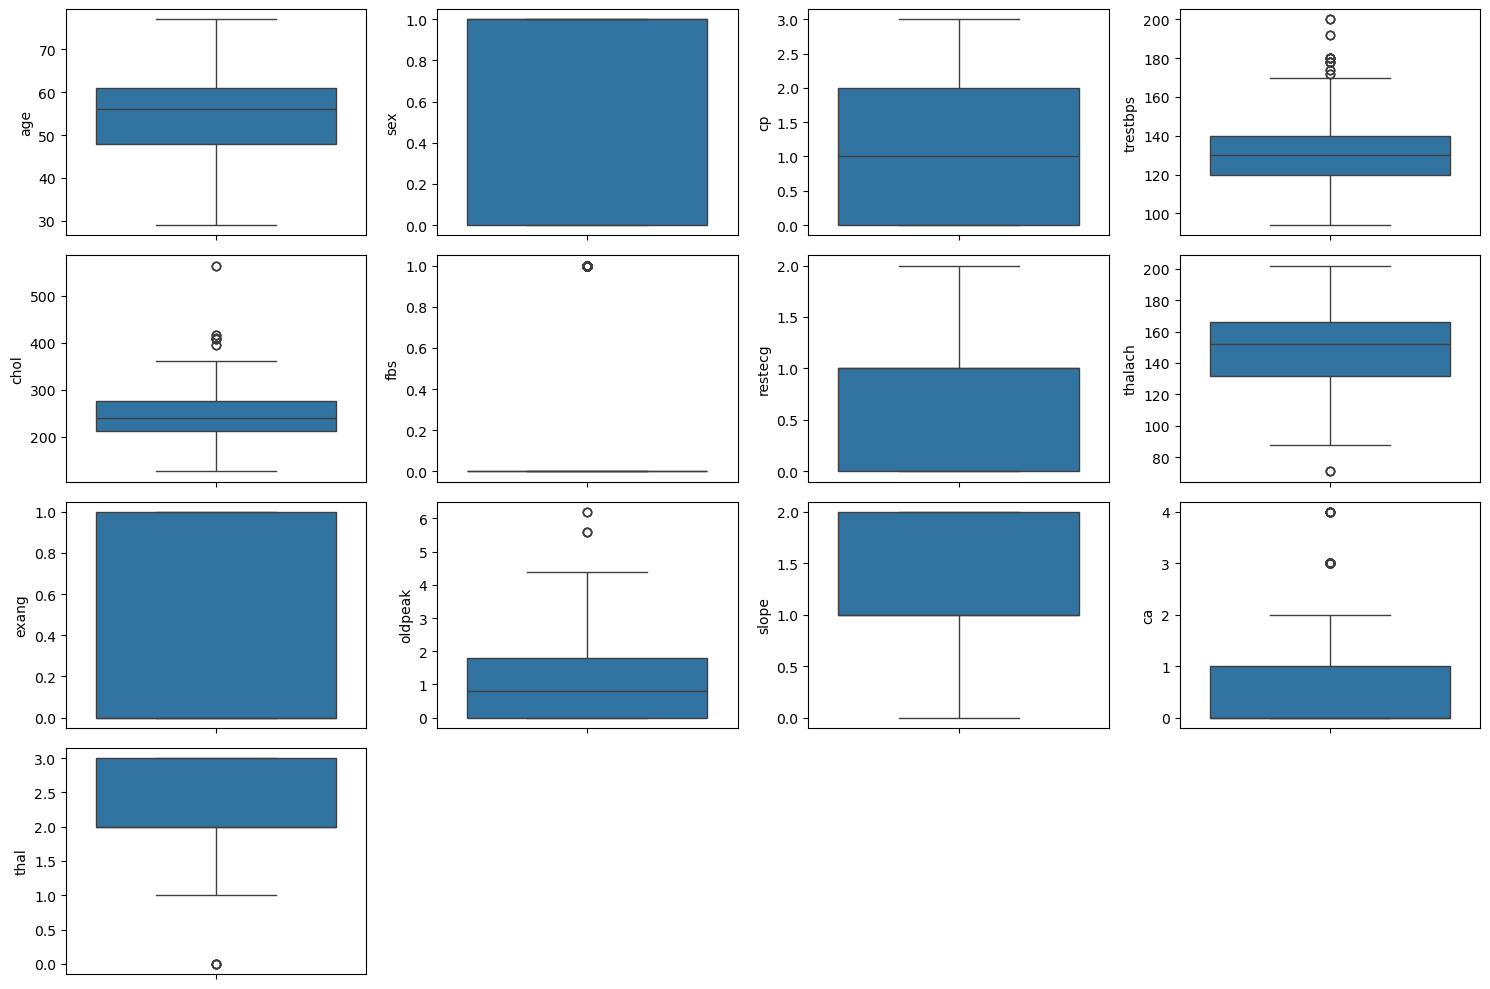

In [12]:
plt.figure(figsize=(15,10))
for i , col in enumerate(df.columns[:-1],1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

# Step 7: Split Data into Training and Testing Sets
The dataset is split into training and testing sets for model evaluation.

In [13]:
X=df.drop('target',axis=1)
y=df['target']

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Step 8: Train KNN
train KNN with k three different  <br>
1) 1 <br>
2) root N
3) N

In [15]:
N = len(X_train)
print("Training Sample = ",N)

Training Sample =  820


In [16]:
knn1 = KNeighborsClassifier(n_neighbors=1)

knn1.fit(X_train,y_train)

y_pred1=knn1.predict(X_test)

print("Accuracy = ",accuracy_score(y_test,y_pred1))

Accuracy =  0.9853658536585366


In [17]:
k_root = int(np.sqrt(N))

knn2 = KNeighborsClassifier(n_neighbors=k_root)

knn2.fit(X_train, y_train)

y_pred2 = knn2.predict(X_test)

print("Accuracy=",accuracy_score(y_test,y_pred2))

Accuracy= 0.7170731707317073


In [18]:
knn3 = KNeighborsClassifier(n_neighbors=N)

knn3.fit(X_train, y_train)

y_pred3 = knn3.predict(X_test)

print("Accuracy=",accuracy_score(y_test,y_pred3))

Accuracy= 0.5121951219512195


# Now train on Z score of Input

# Apply StandardScaler

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# K=1

In [20]:
knn1_scaled = KNeighborsClassifier(n_neighbors=1)

knn1_scaled.fit(X_train_scaled, y_train)

y_pred1_scaled = knn1_scaled.predict(X_test_scaled)

print("Accuracy =", accuracy_score(y_test, y_pred1_scaled))

Accuracy = 1.0


# K=Sqrt(n)

In [21]:
knn2_scaled = KNeighborsClassifier(n_neighbors=k_root)

knn2_scaled.fit(X_train_scaled, y_train)

y_pred2_scaled = knn2_scaled.predict(X_test_scaled)

print("Accuracy =", accuracy_score(y_test, y_pred2_scaled))

Accuracy = 0.848780487804878


# K=n

In [22]:
knn3_scaled = KNeighborsClassifier(n_neighbors=N)

knn3_scaled.fit(X_train_scaled, y_train)

y_pred3_scaled = knn3_scaled.predict(X_test_scaled)

print("Accuracy =", accuracy_score(y_test, y_pred3_scaled))

Accuracy = 0.5121951219512195


In [23]:
results = pd.DataFrame({
    'K Value': [1, k_root, N, 1, k_root, N],
    'Data': [
        'Original',
        'Original',
        'Original',
        'Z-Score',
        'Z-Score',
        'Z-Score'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3),
        accuracy_score(y_test, y_pred1_scaled),
        accuracy_score(y_test, y_pred2_scaled),
        accuracy_score(y_test, y_pred3_scaled)
    ]
})

results

,K Value,Data,Accuracy
0,1,Original,0.985366
1,28,Original,0.717073
2,820,Original,0.512195
3,1,Z-Score,1.000000
4,28,Z-Score,0.848780
5,820,Z-Score,0.512195


# Display confusion matrix and classification Report

In [24]:
cm = confusion_matrix(y_test, y_pred2_scaled)
cm

array([[79, 21],
       [10, 95]])

In [25]:
cr = classification_report(y_test, y_pred2_scaled)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.79      0.84       100
           1       0.82      0.90      0.86       105

    accuracy                           0.85       205
   macro avg       0.85      0.85      0.85       205
weighted avg       0.85      0.85      0.85       205

